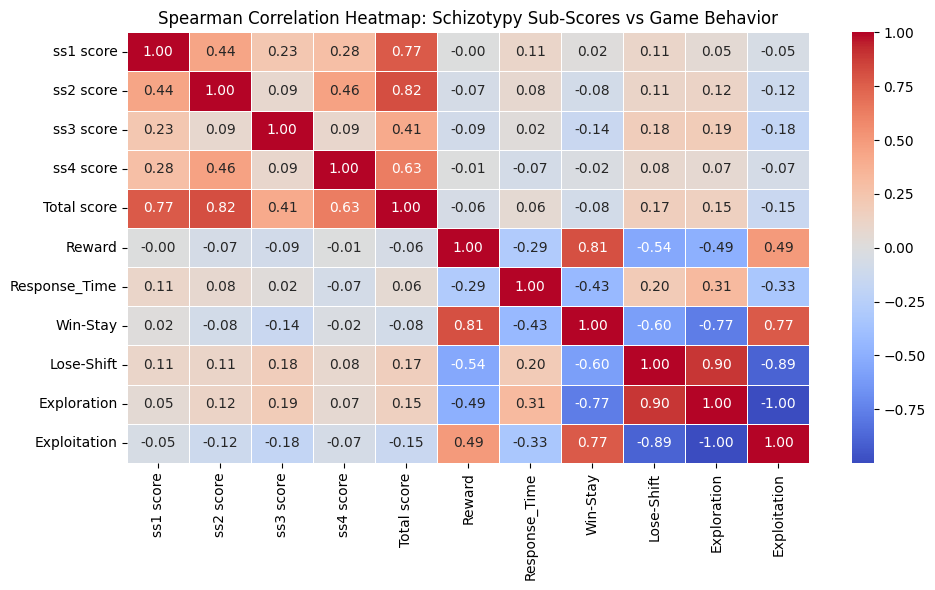

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your data
o_life_df = pd.read_excel("/content/olife_combined.xlsx")
game_data_df = pd.read_csv("/content/Complete game data csv(modified envo).csv")

# Prepare sub-scores data
sub_scores = o_life_df[["ID", "ss1 score", "ss2 score", "ss3 score", "ss4 score", "Total score"]].rename(columns={"ID": "Participant"})

# Aggregate game data by participant
game_summary = game_data_df.groupby(["Participant", "Environment_Type"])[['Reward','Response_Time', 'Win-Stay', 'Lose-Shift', 'Exploration', 'Exploitation']].mean().reset_index()


# Merge the datasets
merged_subscores = pd.merge(sub_scores, game_summary, on="Participant")

# Select only relevant columns
heatmap_data = merged_subscores[["ss1 score", "ss2 score", "ss3 score", "ss4 score", "Total score", 'Reward', 'Response_Time', 'Win-Stay', 'Lose-Shift', 'Exploration', 'Exploitation']]

# Compute Spearman correlation matrix
spearman_corr_matrix = heatmap_data.corr(method='spearman')

# Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(spearman_corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title("Spearman Correlation Heatmap: Schizotypy Sub-Scores vs Game Behavior")
plt.tight_layout()
plt.show()



===== Spearman Correlation Coefficients for High-Fast =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score     -0.01          -0.00     -0.01        0.02         0.02   
ss2 score      0.00           0.10     -0.02        0.05         0.07   
ss3 score     -0.01           0.02     -0.02        0.03         0.04   
ss4 score     -0.03           0.03     -0.06        0.05         0.08   
Total score   -0.01           0.06     -0.03        0.05         0.07   

             Exploitation  
ss1 score           -0.02  
ss2 score           -0.07  
ss3 score           -0.03  
ss4 score           -0.08  
Total score         -0.07  

===== P-values for High-Fast =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score    0.7017         0.8796    0.6037      0.4571       0.4039   
ss2 score    0.9188         0.0000    0.4639      0.0298       0.0046   
ss3 score    0.5201         0.3605    0.4913      0.1313       0.1098   
ss

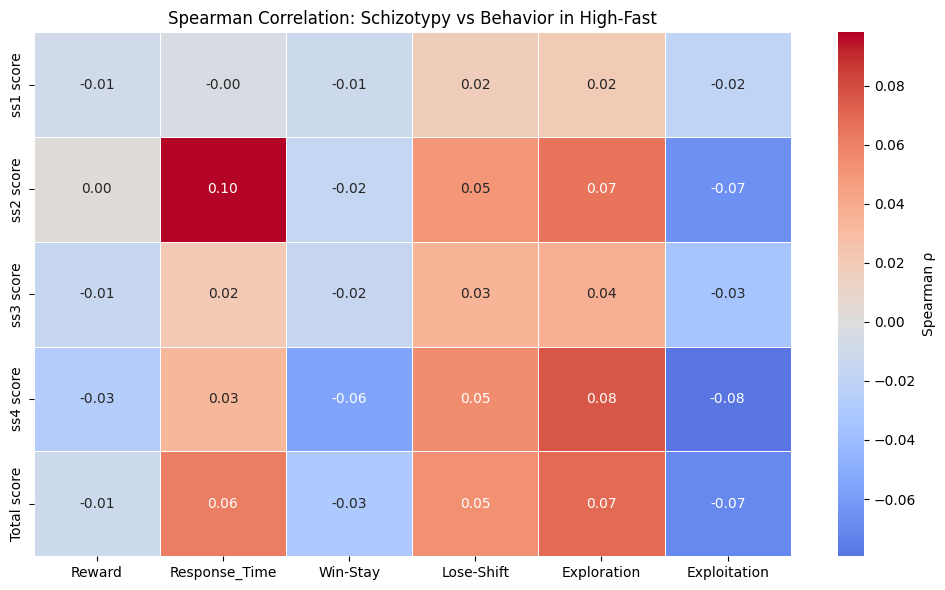

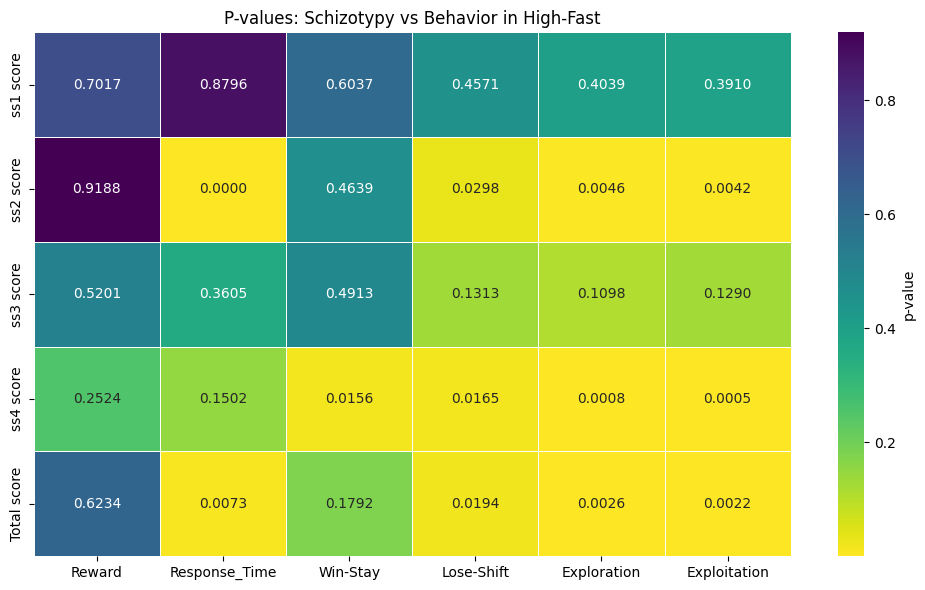


===== Spearman Correlation Coefficients for Low-Slow =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score     -0.03           0.02     -0.04        0.05         0.06   
ss2 score     -0.05          -0.01     -0.07        0.06         0.08   
ss3 score     -0.06           0.07     -0.12        0.13         0.19   
ss4 score      0.01          -0.12      0.02        0.01         0.00   
Total score   -0.05          -0.02     -0.08        0.09         0.11   

             Exploitation  
ss1 score           -0.06  
ss2 score           -0.08  
ss3 score           -0.19  
ss4 score            0.00  
Total score         -0.11  

===== P-values for Low-Slow =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score    0.1898         0.3619    0.0516      0.0200       0.0052   
ss2 score    0.0236         0.5929    0.0015      0.0128       0.0006   
ss3 score    0.0134         0.0013    0.0000      0.0000       0.0000   
ss4 

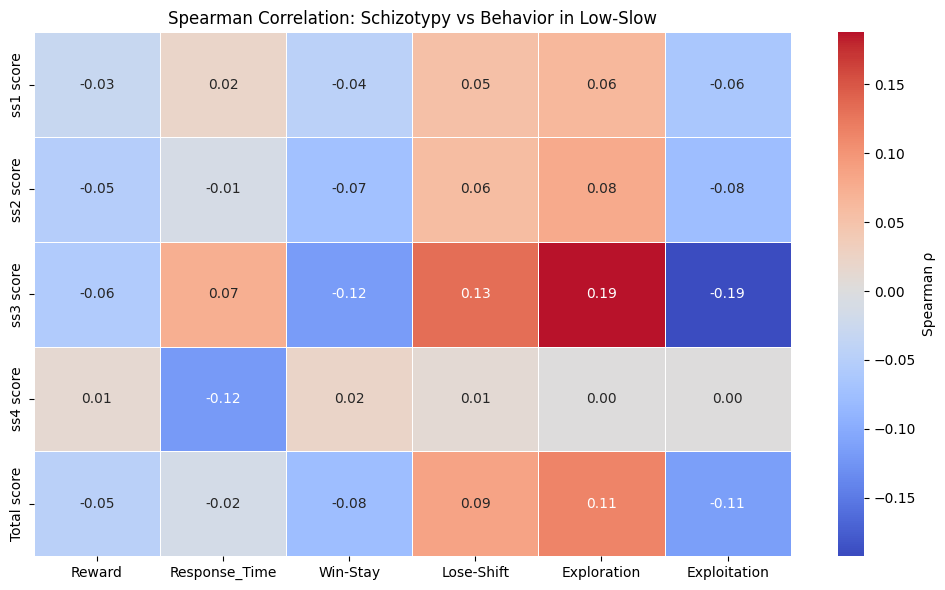

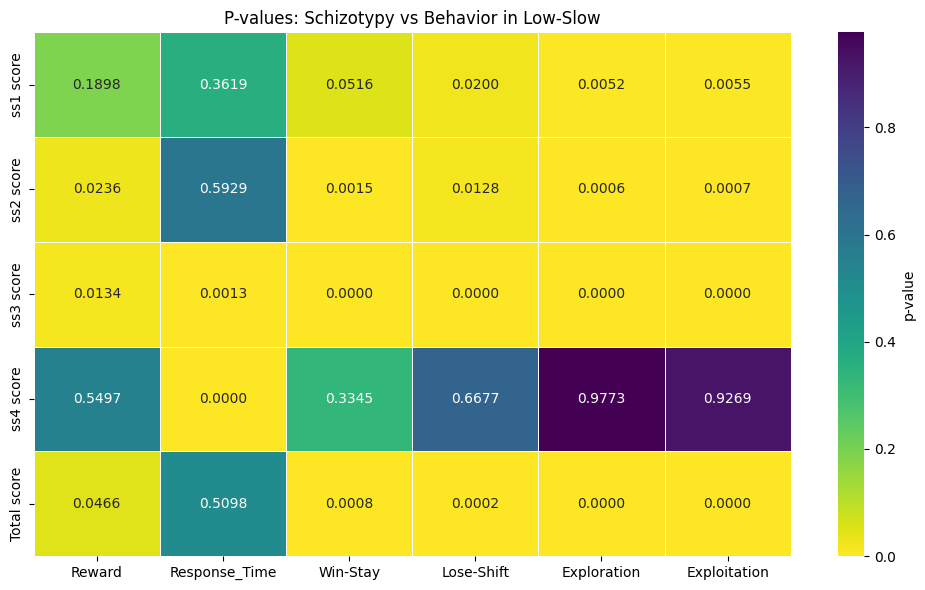


===== Spearman Correlation Coefficients for High-Slow =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score      0.06           0.07      0.05       -0.00         0.00   
ss2 score     -0.02           0.06     -0.05        0.05         0.07   
ss3 score      0.02           0.03     -0.00        0.02         0.04   
ss4 score     -0.02          -0.04     -0.05        0.09         0.11   
Total score    0.01           0.06     -0.02        0.05         0.07   

             Exploitation  
ss1 score           -0.01  
ss2 score           -0.08  
ss3 score           -0.04  
ss4 score           -0.11  
Total score         -0.08  

===== P-values for High-Slow =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score    0.0159         0.0020    0.0206      0.9864       0.9295   
ss2 score    0.2964         0.0077    0.0260      0.0262       0.0014   
ss3 score    0.4887         0.2509    0.9632      0.4515       0.0976   
ss

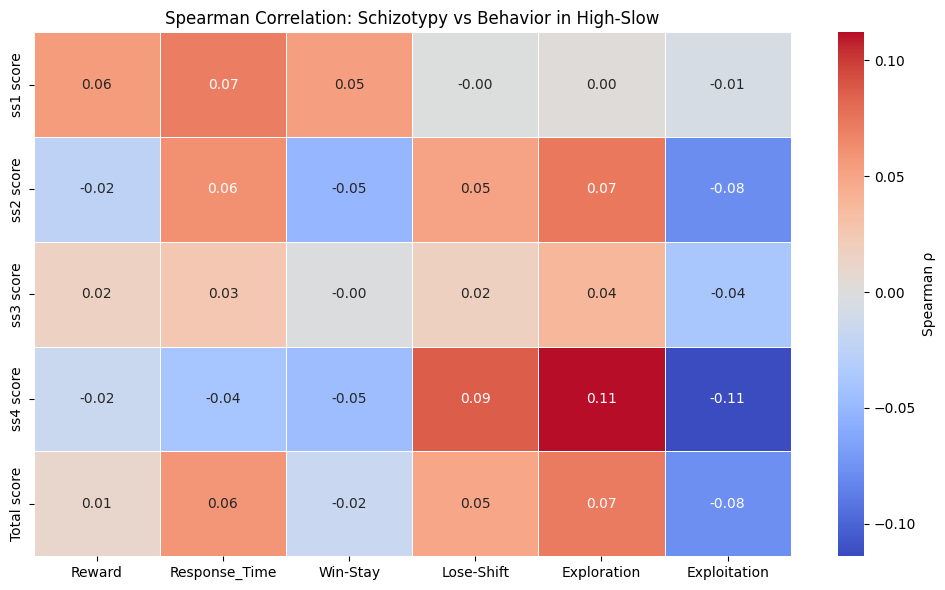

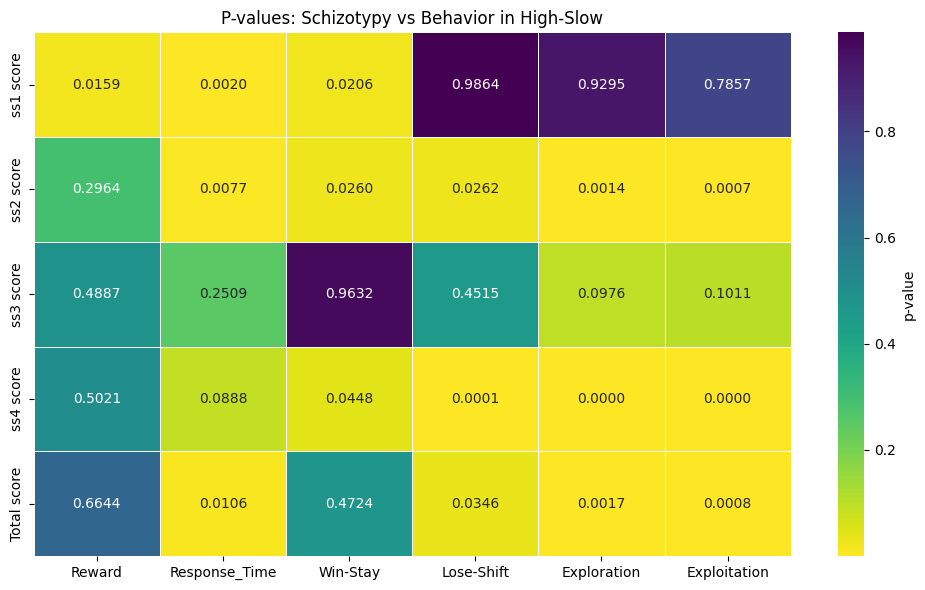


===== Spearman Correlation Coefficients for Low-Fast =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score     -0.05           0.04     -0.02        0.04         0.01   
ss2 score     -0.00          -0.03      0.02       -0.01        -0.03   
ss3 score     -0.04           0.03     -0.07        0.05         0.07   
ss4 score      0.04          -0.08      0.06       -0.02        -0.04   
Total score   -0.02          -0.02     -0.01        0.02         0.01   

             Exploitation  
ss1 score           -0.01  
ss2 score            0.03  
ss3 score           -0.06  
ss4 score            0.04  
Total score          0.00  

===== P-values for Low-Fast =====

             Reward  Response_Time  Win-Stay  Lose-Shift  Exploration  \
ss1 score    0.0401         0.0564    0.4868      0.0504       0.5173   
ss2 score    0.9782         0.1355    0.4369      0.6244       0.2084   
ss3 score    0.0547         0.2739    0.0035      0.0383       0.0044   
ss4 

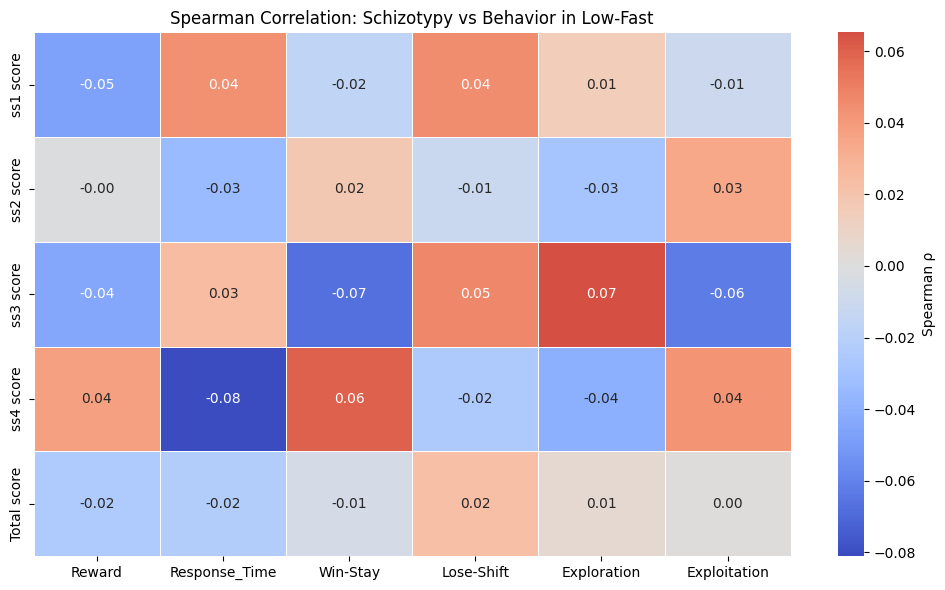

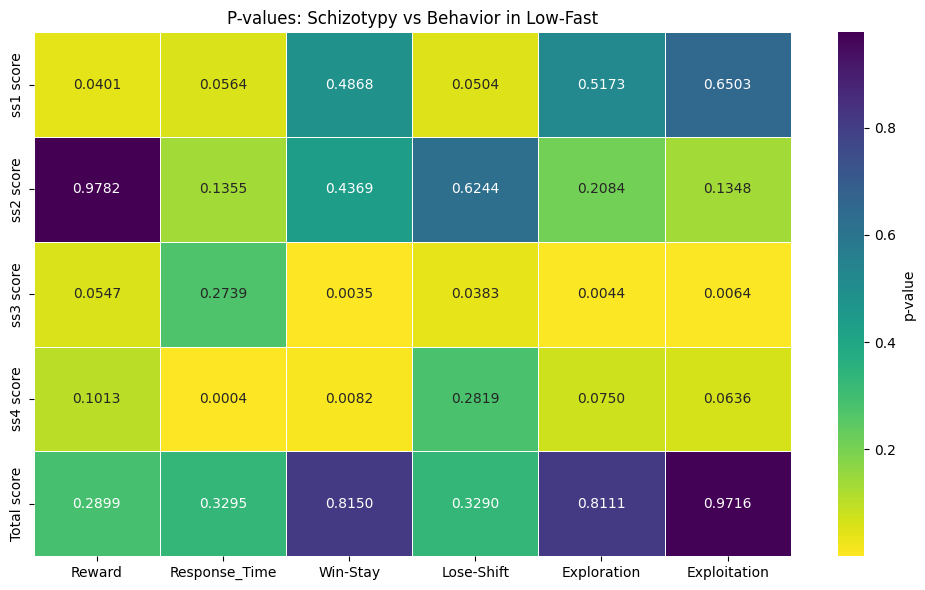

In [2]:
from scipy.stats import spearmanr
import numpy as np

# Load data
o_life_df = pd.read_excel("/content/olife_combined.xlsx")
game_data_df = pd.read_csv("/content/Complete game data csv(modified envo).csv")

# Prepare sub-scores data
sub_scores = o_life_df[["ID", "ss1 score", "ss2 score", "ss3 score", "ss4 score", "Total score"]].rename(columns={"ID": "Participant"})

# Merge full data without aggregating
merged_df = pd.merge(game_data_df, sub_scores, on="Participant")

# Define variables
ss_cols = ["ss1 score", "ss2 score", "ss3 score", "ss4 score", "Total score"]
behavior_cols = ['Reward', 'Response_Time', 'Win-Stay', 'Lose-Shift', 'Exploration', 'Exploitation']
all_cols = ss_cols + behavior_cols

# Get unique environment types
env_types = merged_df['Environment_Type'].unique()

for env in env_types:
    subset = merged_df[merged_df['Environment_Type'] == env]

    # Drop rows with NaNs for safe computation
    data = subset[all_cols].dropna()

    # Compute Spearman correlation and p-values
    corr_matrix, p_matrix = spearmanr(data)

    # Convert to DataFrames
    corr_df = pd.DataFrame(corr_matrix, index=all_cols, columns=all_cols)
    pval_df = pd.DataFrame(p_matrix, index=all_cols, columns=all_cols)

    # Slice only schizotypy-behavior correlations and p-values
    corr_slice = corr_df.loc[ss_cols, behavior_cols]
    pval_slice = pval_df.loc[ss_cols, behavior_cols]

    # Print results
    print(f"\n===== Spearman Correlation Coefficients for {env} =====\n")
    print(corr_slice.round(2))
    print(f"\n===== P-values for {env} =====\n")
    print(pval_slice.round(4))

    # Plot correlation heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr_slice, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5,
                cbar_kws={'label': 'Spearman ρ'})
    plt.title(f"Spearman Correlation: Schizotypy vs Behavior in {env}")
    plt.tight_layout()
    plt.show()

    # Optional: Plot p-values as a heatmap
    plt.figure(figsize=(10, 6))
    sns.heatmap(pval_slice, annot=True, cmap='viridis_r', fmt=".4f", linewidths=0.5,
                cbar_kws={'label': 'p-value'})
    plt.title(f"P-values: Schizotypy vs Behavior in {env}")
    plt.tight_layout()
    plt.show()


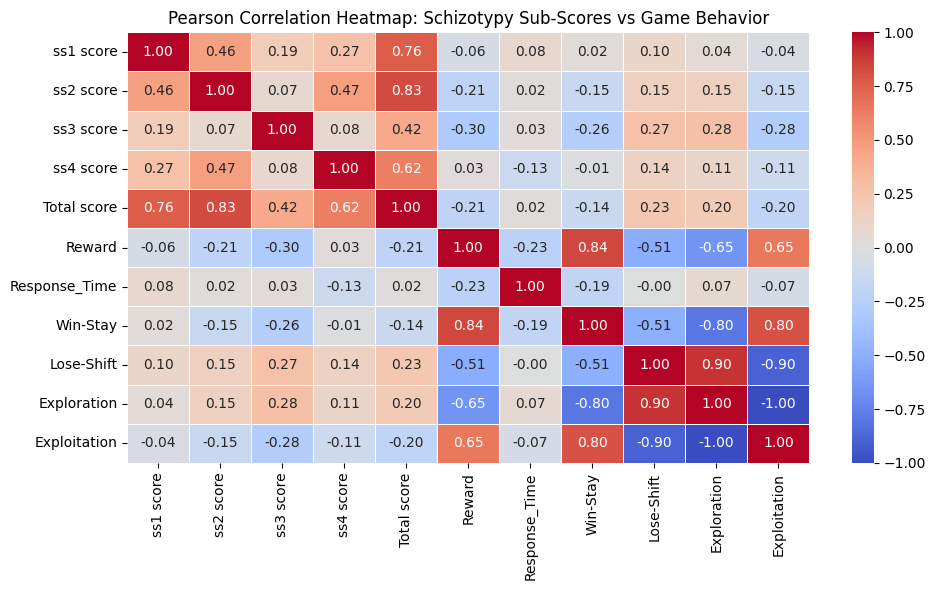

In [3]:
o_life_df = pd.read_excel("/content/olife_combined.xlsx")
game_data_df = pd.read_csv("/content/Complete game data csv(modified envo).csv")

# Prepare sub-scores data
sub_scores = o_life_df[["ID", "ss1 score", "ss2 score", "ss3 score", "ss4 score", "Total score"]].rename(columns={"ID": "Participant"})

# Aggregate game data by participant
game_summary = game_data_df.groupby("Participant")[['Reward', 'Response_Time', 'Win-Stay', 'Lose-Shift', 'Exploration', 'Exploitation']].mean().reset_index()

# Merge the datasets
merged_subscores = pd.merge(sub_scores, game_summary, on="Participant")

# Select relevant columns
heatmap_data = merged_subscores[["ss1 score", "ss2 score", "ss3 score", "ss4 score", "Total score", 'Reward', 'Response_Time', 'Win-Stay', 'Lose-Shift', 'Exploration', 'Exploitation']]

# Compute Pearson correlation matrix
pearson_corr_matrix = heatmap_data.corr(method='pearson')

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pearson_corr_matrix, annot=True, cmap='coolwarm', center=0, fmt=".2f", linewidths=0.5)
plt.title("Pearson Correlation Heatmap: Schizotypy Sub-Scores vs Game Behavior")
plt.tight_layout()
plt.show()

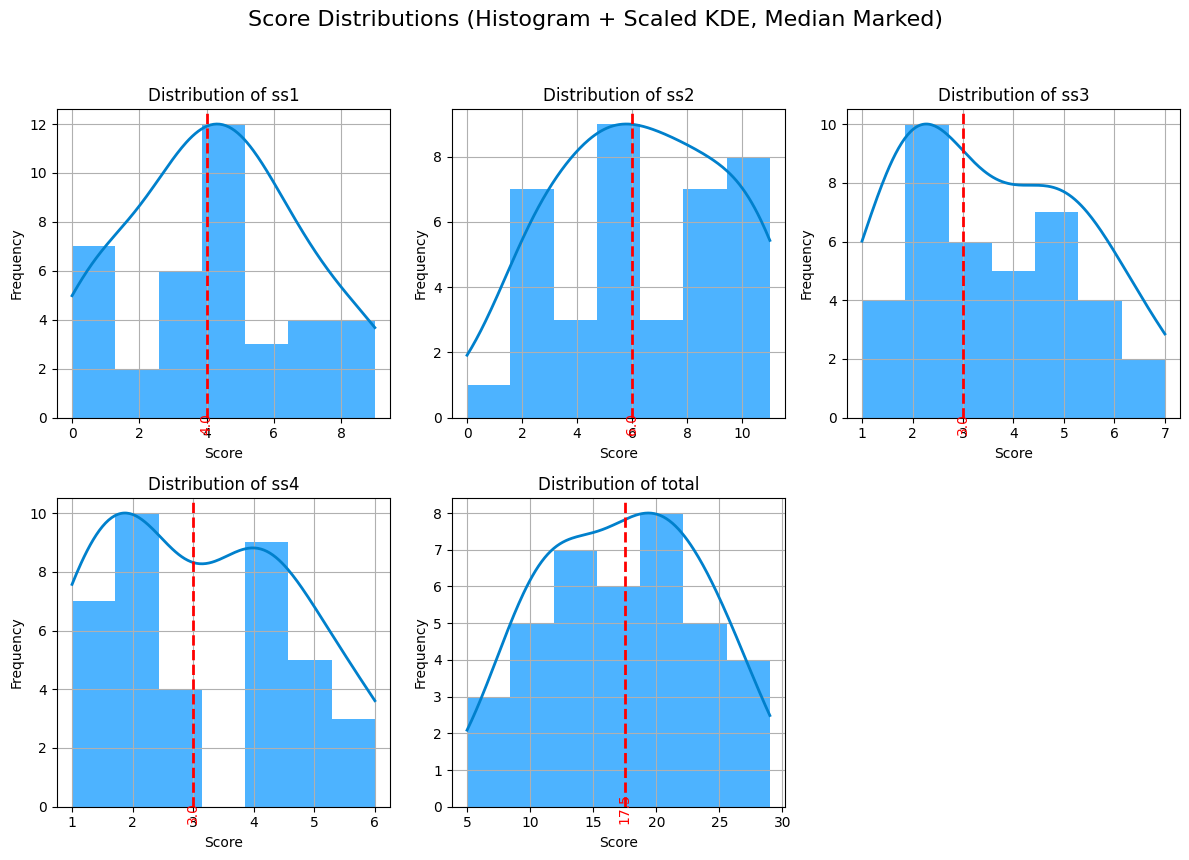

In [4]:
from scipy.stats import gaussian_kde

# Example data (replace with your actual data)
ss1 = np.array([9, 6, 5, 4, 5, 3, 8, 6, 3, 0, 0, 1, 2, 4, 6, 5, 5, 9, 3, 7, 5, 1, 1, 4, 0, 9, 5, 3, 1, 7, 2, 7, 5, 7, 3, 4, 4, 3])
ss2 = np.array([11, 8, 2, 7, 6, 3, 11, 8, 10, 0, 6, 9, 2, 11, 10, 3, 6, 7, 11, 5, 10, 2, 7, 8, 2, 8, 8, 5, 5, 4, 5, 10, 4, 9, 5, 4, 6, 3])
ss3 = np.array([2, 3, 4, 3, 5, 5, 7, 4, 5, 6, 1, 2, 3, 6, 4, 1, 7, 2, 2, 6, 4, 3, 2, 4, 2, 3, 6, 1, 5, 5, 2, 3, 5, 2, 1, 2, 5, 2])
ss4 = np.array([5, 4, 2, 2, 1, 2, 3, 2, 6, 3, 4, 4, 1, 6, 4, 4, 2, 3, 2, 5, 5, 2, 1, 4, 1, 4, 1, 3, 4, 2, 5, 6, 5, 4, 1, 2, 2, 1])

data = np.column_stack((ss1, ss2, ss3, ss4))
total = np.sum(data, axis=1)
all_scores = np.column_stack((data, total))

score_names = ['ss1', 'ss2', 'ss3', 'ss4', 'total']

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 9))
axes = axes.flatten()

for i in range(5):
    ax = axes[i]
    scores = all_scores[:, i]

    # Histogram
    hist = ax.hist(scores, bins='auto', color=(0.3, 0.7, 1), edgecolor='none', alpha=1.0)

    # KDE
    kde = gaussian_kde(scores)
    xi = np.linspace(min(scores), max(scores), 200)
    f = kde(xi)
    f_scaled = f * max(hist[0]) / max(f)
    ax.plot(xi, f_scaled, color=(0, 0.5, 0.8), linewidth=2)

    # Median
    med = np.median(scores)
    ax.axvline(med, color='r', linestyle='--', linewidth=2)
    ax.text(med, -0.05 * max(hist[0]), f'{med:.1f}', color='r',
            fontsize=10, ha='center', rotation=90)

    ax.set_title(f'Distribution of {score_names[i]}')
    ax.set_xlabel('Score')
    ax.set_ylabel('Frequency')
    ax.grid(True)

# Remove the unused subplot
fig.delaxes(axes[-1])

fig.suptitle('Score Distributions (Histogram + Scaled KDE, Median Marked)', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
